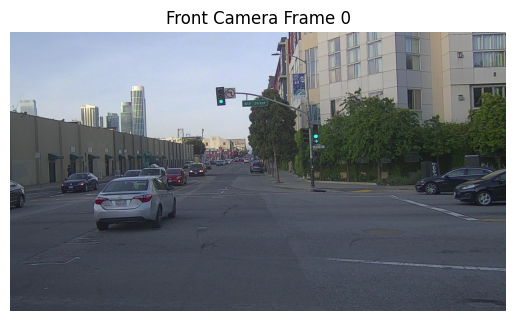

In [2]:
import cv2
import matplotlib.pyplot as plt
import json
from pathlib import Path

# Example: load one front camera image
img_path = Path("/media/bvb/SSD-1/panda/pandaset-devkit-master/data/pandaset/001/camera/front_camera/00.jpg")
image = cv2.imread(str(img_path))
image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

plt.imshow(image)
plt.title("Front Camera Frame 0")
plt.axis("off")
plt.show()


In [3]:
import json

intrinsics = json.load(open("/media/bvb/SSD-1/panda/pandaset-devkit-master/data/pandaset/001/camera/front_camera/intrinsics.json"))
poses = json.load(open("/media/bvb/SSD-1/panda/pandaset-devkit-master/data/pandaset/001/camera/front_camera/poses.json"))

print("Intrinsics:", intrinsics)
print("First pose:", poses[0])


Intrinsics: {'fx': 1970.0131, 'fy': 1970.0091, 'cx': 970.0002, 'cy': 483.2988}
First pose: {'position': {'x': 0.4089946812412687, 'y': 0.2613134190711932, 'z': 1.8091555545899585}, 'heading': {'w': 0.6578225673496162, 'x': -0.6474123760158749, 'y': 0.28335991415664824, 'z': -0.2604493123741657}}


In [5]:
import pickle
import matplotlib.pyplot as plt

lidar_file = "/media/bvb/SSD-1/panda/pandaset-devkit-master/data/pandaset/001/lidar/00.pkl"

with open(lidar_file, 'rb') as f:
    lidar_data = pickle.load(f)

print("Type:", type(lidar_data))
print("Columns:", lidar_data.columns if hasattr(lidar_data, "columns") else "Not a DataFrame")

# If it's a DataFrame, convert to numpy
if hasattr(lidar_data, "values"):
    lidar_np = lidar_data.values   # shape (N, 5)
else:
    lidar_np = lidar_data          # already numpy

print("Shape:", lidar_np.shape)
print("First row:", lidar_np[0])


Type: <class 'pandas.core.frame.DataFrame'>
Columns: Index(['x', 'y', 'z', 'i', 't', 'd'], dtype='object')
Shape: (169171, 6)
First row: [-5.84571991e+01 -6.12692680e+01  2.88101435e+00  3.90000000e+01
  1.55753992e+09  0.00000000e+00]


Type: <class 'pandas.core.frame.DataFrame'>
Columns: Index(['x', 'y', 'z', 'i', 't', 'd'], dtype='object')
Shape: (169171, 6)
First row:
 x   -5.845720e+01
y   -6.126927e+01
z    2.881014e+00
i    3.900000e+01
t    1.557540e+09
d    0.000000e+00
Name: 0, dtype: float64


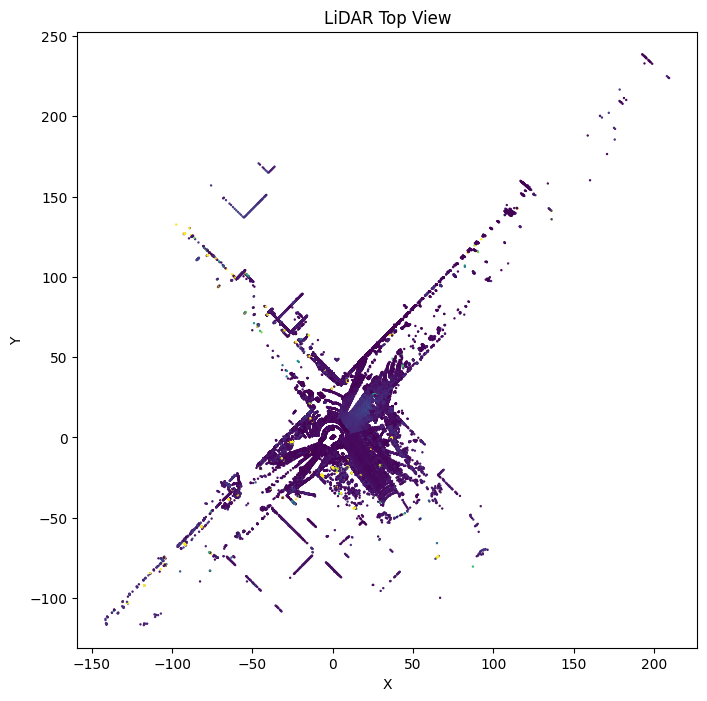

In [6]:
import pickle
import matplotlib.pyplot as plt

# Load LiDAR DataFrame
lidar_file = "/media/bvb/SSD-1/panda/pandaset-devkit-master/data/pandaset/001/lidar/00.pkl"

with open(lidar_file, 'rb') as f:
    lidar_df = pickle.load(f)

print("Type:", type(lidar_df))
print("Columns:", lidar_df.columns)
print("Shape:", lidar_df.shape)
print("First row:\n", lidar_df.iloc[0])

# Bird’s-eye view scatter plot
plt.figure(figsize=(8,8))
plt.scatter(lidar_df["x"], lidar_df["y"],
            s=0.5, c=lidar_df["i"], cmap="viridis")
plt.xlabel("X")
plt.ylabel("Y")
plt.title("LiDAR Top View")
plt.axis("equal")
plt.show()


In [9]:
import pickle

cuboid_file = "/media/bvb/SSD-1/panda/pandaset-devkit-master/data/pandaset/001/annotations/cuboids/00.pkl"

with open(cuboid_file, 'rb') as f:
    cuboids = pickle.load(f)

print("Type:", type(cuboids))
print("Keys:", cuboids.keys() if isinstance(cuboids, dict) else "No keys")


Type: <class 'pandas.core.frame.DataFrame'>
Keys: No keys


KeyError: 'cuboids'

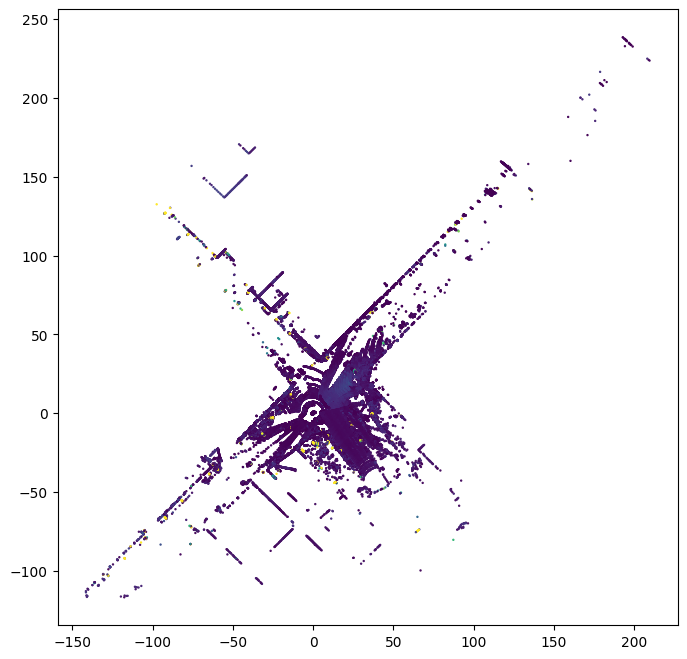

In [10]:
import numpy as np
import matplotlib.pyplot as plt

def draw_cuboid(ax, cuboid, color="red"):
    cx, cy, cz = cuboid["position"]
    length, width, height = cuboid["dimensions"]
    yaw = cuboid["yaw"]
    
    # Rectangle corners in local frame
    corners = np.array([
        [ length/2,  width/2],
        [ length/2, -width/2],
        [-length/2, -width/2],
        [-length/2,  width/2]
    ])
    
    # Rotation matrix
    R = np.array([[np.cos(yaw), -np.sin(yaw)],
                  [np.sin(yaw),  np.cos(yaw)]])
    
    # Rotate and translate
    rotated = (R @ corners.T).T
    translated = rotated + np.array([cx, cy])
    
    # Close the rectangle
    polygon = np.vstack([translated, translated[0]])
    ax.plot(polygon[:,0], polygon[:,1], color=color, linewidth=1)

# Plot LiDAR with cuboids
fig, ax = plt.subplots(figsize=(8,8))
ax.scatter(lidar_df["x"], lidar_df["y"], s=0.5, c=lidar_df["i"], cmap="viridis")

for c in cuboids["cuboids"]:
    draw_cuboid(ax, c, color="red")

ax.set_xlabel("X")
ax.set_ylabel("Y")
ax.set_title("LiDAR + Cuboid Annotations")
ax.axis("equal")
plt.show()


NameError: name 'cuboids' is not defined

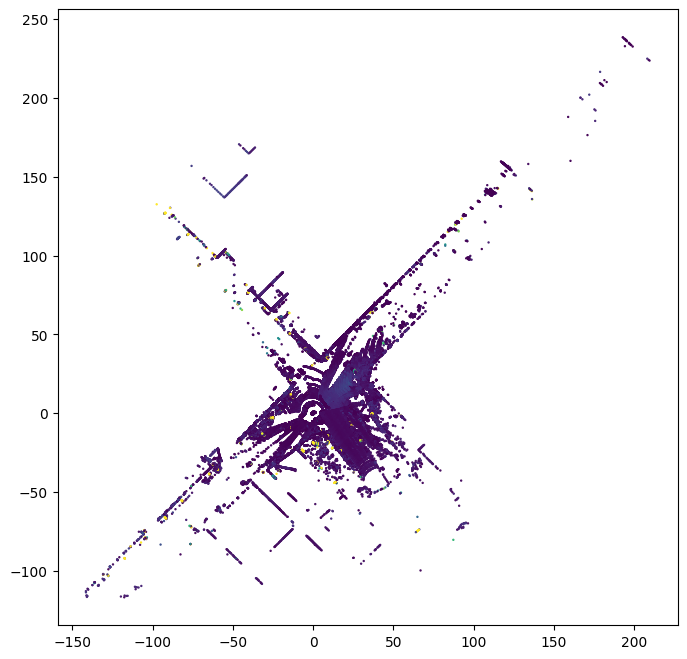

In [7]:
import numpy as np
import matplotlib.pyplot as plt

def draw_cuboid(ax, pos, dims, yaw, color="red"):
    cx, cy, cz = pos
    length, width, height = dims
    
    # Rectangle corners in local frame
    corners = np.array([
        [ length/2,  width/2],
        [ length/2, -width/2],
        [-length/2, -width/2],
        [-length/2,  width/2]
    ])
    
    # Rotation matrix
    R = np.array([[np.cos(yaw), -np.sin(yaw)],
                  [np.sin(yaw),  np.cos(yaw)]])
    
    # Rotate and translate
    rotated = (R @ corners.T).T
    translated = rotated + np.array([cx, cy])
    
    # Close the polygon
    polygon = np.vstack([translated, translated[0]])
    ax.plot(polygon[:,0], polygon[:,1], color=color, linewidth=1)

# Example overlay
fig, ax = plt.subplots(figsize=(8,8))
ax.scatter(lidar_df["x"], lidar_df["y"], s=0.5, c=lidar_df["i"], cmap="viridis")

for _, row in cuboids.iterrows():
    draw_cuboid(ax, row["position"], row["dimensions"], row["yaw"], color="red")

ax.set_xlabel("X")
ax.set_ylabel("Y")
ax.set_title("LiDAR + Cuboids (Bird’s-eye view)")
ax.axis("equal")
plt.show()


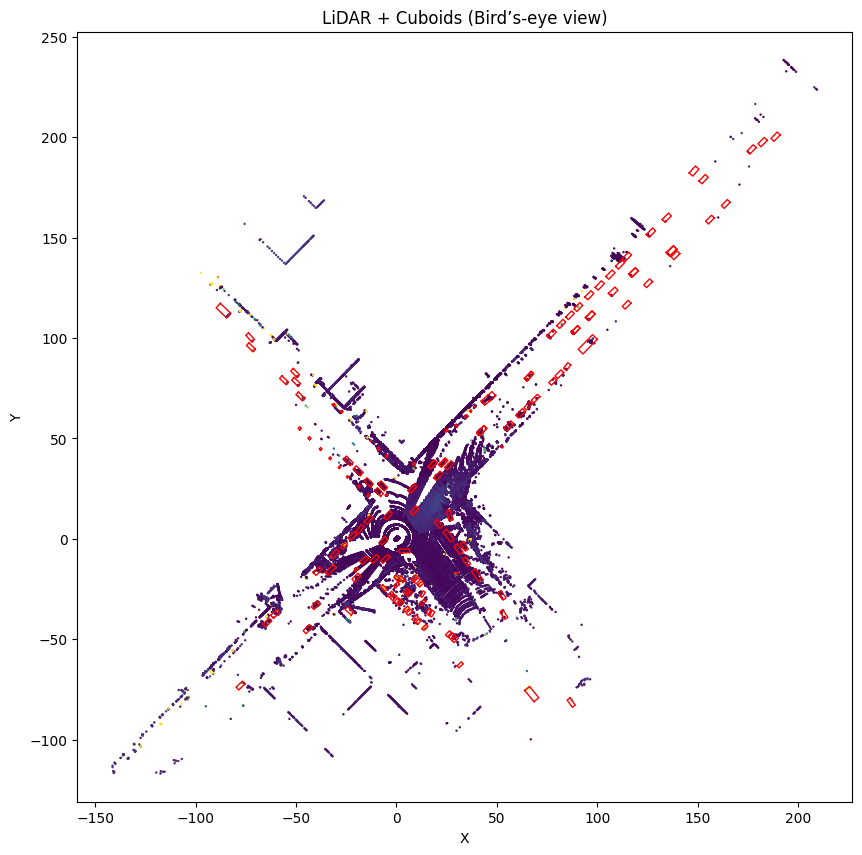

In [11]:
import numpy as np
import matplotlib.pyplot as plt

def draw_cuboid(ax, row, color="red"):
    cx, cy = row["position.x"], row["position.y"]
    length, width = row["dimensions.x"], row["dimensions.y"]
    yaw = row["yaw"]
    
    # Rectangle corners in local frame
    corners = np.array([
        [ length/2,  width/2],
        [ length/2, -width/2],
        [-length/2, -width/2],
        [-length/2,  width/2]
    ])
    
    # Rotation matrix
    R = np.array([[np.cos(yaw), -np.sin(yaw)],
                  [np.sin(yaw),  np.cos(yaw)]])
    
    # Rotate and translate
    rotated = (R @ corners.T).T
    translated = rotated + np.array([cx, cy])
    
    # Close the rectangle
    polygon = np.vstack([translated, translated[0]])
    ax.plot(polygon[:,0], polygon[:,1], color=color, linewidth=1)

# Plot LiDAR + Cuboids
fig, ax = plt.subplots(figsize=(10,10))
ax.scatter(lidar_df["x"], lidar_df["y"], s=0.5, c=lidar_df["i"], cmap="viridis")

for _, row in cuboids.iterrows():
    draw_cuboid(ax, row, color="red")

ax.set_xlabel("X")
ax.set_ylabel("Y")
ax.set_title("LiDAR + Cuboids (Bird’s-eye view)")
ax.axis("equal")
plt.show()


In [10]:
import pickle
import numpy as np
import open3d as o3d

# --- Load LiDAR ---
lidar_file = "/media/bvb/SSD-1/panda/pandaset-devkit-master/data/pandaset/001/lidar/00.pkl"

with open(lidar_file, 'rb') as f:
    lidar_df = pickle.load(f)   # DataFrame with columns: x, y, z, i, t, d

print("LiDAR shape:", lidar_df.shape)

# --- Convert LiDAR to Open3D point cloud ---
pcd = o3d.geometry.PointCloud()
points = lidar_df[["x", "y", "z"]].values
pcd.points = o3d.utility.Vector3dVector(points)

# Use intensity for coloring
intensity = lidar_df["i"].values
intensity_norm = (intensity - intensity.min()) / (intensity.max() - intensity.min())
pcd.colors = o3d.utility.Vector3dVector(np.repeat(intensity_norm[:, None], 3, axis=1))

# --- Load cuboids ---
cuboid_file = "/media/bvb/SSD-1/panda/pandaset-devkit-master/data/pandaset/001/annotations/cuboids/00.pkl"

with open(cuboid_file, 'rb') as f:
    cuboids = pickle.load(f)   # DataFrame

print("Cuboids shape:", cuboids.shape)

# --- Function to create 3D bounding box ---
def create_bbox(row, color=[1, 0, 0]):
    cx, cy, cz = row["position.x"], row["position.y"], row["position.z"]
    l, w, h = row["dimensions.x"], row["dimensions.y"], row["dimensions.z"]
    yaw = row["yaw"]

    bbox = o3d.geometry.OrientedBoundingBox(
        center=[cx, cy, cz],
        R=o3d.geometry.OrientedBoundingBox.get_rotation_matrix_from_axis_angle([0, 0, yaw]),
        extent=[l, w, h]
    )
    bbox.color = color
    return bbox

# --- Create all cuboid boxes ---
boxes = [create_bbox(row) for _, row in cuboids.iterrows()]

# --- Visualize ---
o3d.visualization.draw_geometries([pcd] + boxes)


Jupyter environment detected. Enabling Open3D WebVisualizer.
[Open3D INFO] WebRTC GUI backend enabled.
[Open3D INFO] WebRTCWindowSystem: HTTP handshake server disabled.
LiDAR shape: (169171, 6)
Cuboids shape: (151, 17)


In [12]:
import matplotlib.colors as mcolors

# Define color map for object classes
label_colors = {
    "Car": [1, 0, 0],              # red
    "Truck": [0, 0, 1],            # blue
    "Bus": [0, 1, 0],              # green
    "Pedestrian": [1, 1, 0],       # yellow
    "Bicycle": [1, 0, 1],          # magenta
    "Motorcycle": [0, 1, 1],       # cyan
}

def create_bbox(row):
    cx, cy, cz = row["position.x"], row["position.y"], row["position.z"]
    l, w, h = row["dimensions.x"], row["dimensions.y"], row["dimensions.z"]
    yaw = row["yaw"]
    
    # Pick color based on label, default gray if unknown
    color = label_colors.get(row["label"], [0.5, 0.5, 0.5])
    
    bbox = o3d.geometry.OrientedBoundingBox(
        center=[cx, cy, cz],
        R=o3d.geometry.OrientedBoundingBox.get_rotation_matrix_from_axis_angle([0, 0, yaw]),
        extent=[l, w, h]
    )
    bbox.color = color
    return bbox

# Create cuboids with per-class colors
boxes = [create_bbox(row) for _, row in cuboids.iterrows()]

# Visualize
o3d.visualization.draw_geometries([pcd] + boxes)


In [12]:
print(cuboids["label"].unique())
print("Total unique classes:", cuboids["label"].nunique())


['Car' 'Other Vehicle - Uncommon' 'Towed Object' 'Cones' 'Pedestrian'
 'Pickup Truck' 'Personal Mobility Device' 'Construction Signs'
 'Other Vehicle - Construction Vehicle' 'Signs' 'Motorcycle' 'Semi-truck']
Total unique classes: 12


In [13]:
print(cuboids["label"].value_counts())


label
Car                                     88
Other Vehicle - Uncommon                27
Construction Signs                      14
Cones                                    7
Pickup Truck                             4
Pedestrian                               4
Other Vehicle - Construction Vehicle     2
Towed Object                             1
Personal Mobility Device                 1
Signs                                    1
Motorcycle                               1
Semi-truck                               1
Name: count, dtype: int64


In [14]:
import pickle
import pandas as pd

# Load cuboids
cuboid_file = "/media/bvb/SSD-1/panda/pandaset-devkit-master/data/pandaset/001/annotations/cuboids/00.pkl"
with open(cuboid_file, 'rb') as f:
    cuboids = pickle.load(f)

print("Original labels:", cuboids["label"].unique())

# Mapping function
def simplify_label(label):
    vehicle_classes = ["Car", "Pickup Truck", "Semi-truck", "Bus",
                       "Other Vehicle - Uncommon", "Other Vehicle - Construction Vehicle"]
    pedestrian_classes = ["Pedestrian", "Personal Mobility Device"]
    cyclist_classes = ["Bicycle", "Motorcycle"]

    if label in vehicle_classes:
        return "Vehicle"
    elif label in pedestrian_classes:
        return "Pedestrian"
    elif label in cyclist_classes:
        return "Cyclist"
    else:
        return None   # ignored classes

# Apply mapping
cuboids["new_label"] = cuboids["label"].apply(simplify_label)

# Keep only rows with Vehicle, Pedestrian, Cyclist
filtered = cuboids.dropna(subset=["new_label"])
print(filtered["new_label"].value_counts())


Original labels: ['Car' 'Other Vehicle - Uncommon' 'Towed Object' 'Cones' 'Pedestrian'
 'Pickup Truck' 'Personal Mobility Device' 'Construction Signs'
 'Other Vehicle - Construction Vehicle' 'Signs' 'Motorcycle' 'Semi-truck']
new_label
Vehicle       122
Pedestrian      5
Cyclist         1
Name: count, dtype: int64


In [20]:
import pickle
import os
import pandas as pd

# --- Paths ---
base_path = "/media/bvb/SSD-1/panda/pandaset-devkit-master/data/pandaset/001/annotations/cuboids"
out_path = "/media/bvb/SSD-1/panda/pandaset-devkit-master/data/pandaset/001/annotations/cuboids_simplified"

os.makedirs(out_path, exist_ok=True)

# --- Mapping function ---
def simplify_label(label):
    vehicle_classes = ["Car", "Pickup Truck", "Semi-truck", "Bus",
                       "Other Vehicle - Uncommon", "Other Vehicle - Construction Vehicle"]
    pedestrian_classes = ["Pedestrian", "Personal Mobility Device"]
    cyclist_classes = ["Bicycle", "Motorcycle"]

    if label in vehicle_classes:
        return "Vehicle"
    elif label in pedestrian_classes:
        return "Pedestrian"
    elif label in cyclist_classes:
        return "Cyclist"
    else:
        return None   # ignored

# --- Process all frames ---
for frame in range(80):  # 00.pkl to 79.pkl
    file_in = os.path.join(base_path, f"{frame:02d}.pkl")
    file_out = os.path.join(out_path, f"{frame:02d}.pkl")

    # Load original cuboids (pandas DataFrame)
    with open(file_in, "rb") as f:
        cuboids = pickle.load(f)

    # Simplify labels
    cuboids["new_label"] = cuboids["label"].apply(simplify_label)
    filtered = cuboids.dropna(subset=["new_label"])

    # Save as list of dicts (portable)
    with open(file_out, "wb") as f:
        pickle.dump(filtered.to_dict("records"), f)

    print(f"Frame {frame:02d}: {len(filtered)} simplified cuboids saved → {file_out}")


Frame 00: 128 simplified cuboids saved → /media/bvb/SSD-1/panda/pandaset-devkit-master/data/pandaset/001/annotations/cuboids_simplified/00.pkl
Frame 01: 132 simplified cuboids saved → /media/bvb/SSD-1/panda/pandaset-devkit-master/data/pandaset/001/annotations/cuboids_simplified/01.pkl
Frame 02: 135 simplified cuboids saved → /media/bvb/SSD-1/panda/pandaset-devkit-master/data/pandaset/001/annotations/cuboids_simplified/02.pkl
Frame 03: 135 simplified cuboids saved → /media/bvb/SSD-1/panda/pandaset-devkit-master/data/pandaset/001/annotations/cuboids_simplified/03.pkl
Frame 04: 136 simplified cuboids saved → /media/bvb/SSD-1/panda/pandaset-devkit-master/data/pandaset/001/annotations/cuboids_simplified/04.pkl
Frame 05: 136 simplified cuboids saved → /media/bvb/SSD-1/panda/pandaset-devkit-master/data/pandaset/001/annotations/cuboids_simplified/05.pkl
Frame 06: 136 simplified cuboids saved → /media/bvb/SSD-1/panda/pandaset-devkit-master/data/pandaset/001/annotations/cuboids_simplified/06.pkl

In [21]:
import os, pickle, pandas as pd

counts = {"Vehicle": 0, "Pedestrian": 0, "Cyclist": 0}
out_path = "/media/bvb/SSD-1/panda/pandaset-devkit-master/data/pandaset/001/annotations/cuboids_simplified"

for frame in range(80):
    file = os.path.join(out_path, f"{frame:02d}.pkl")
    with open(file, "rb") as f:
        records = pickle.load(f)
    df = pd.DataFrame.from_records(records)
    counts["Vehicle"] += (df["new_label"] == "Vehicle").sum()
    counts["Pedestrian"] += (df["new_label"] == "Pedestrian").sum()
    counts["Cyclist"] += (df["new_label"] == "Cyclist").sum()

print("Total across sequence:", counts)


Total across sequence: {'Vehicle': np.int64(9465), 'Pedestrian': np.int64(545), 'Cyclist': np.int64(80)}


In [24]:
import pickle
import numpy as np
import pandas as pd

# inputs
seq_base = "/media/bvb/SSD-1/panda/pandaset-devkit-master/data/pandaset/001"
lidar_file = f"{seq_base}/lidar/00.pkl"
cuboid_file = f"{seq_base}/annotations/cuboids_simplified/00.pkl"   # list of dicts

# parameters
fov_deg = 60.0       # total horizontal field of view of forward sensor
min_range = 0.0      # meters
max_range = 120.0    # meters

# load lidar
with open(lidar_file, "rb") as f:
    lidar_df = pickle.load(f)  # pandas DataFrame with columns x y z i t d

# compute azimuth and range
angles = np.arctan2(lidar_df["y"].values, lidar_df["x"].values)   # radians
ranges = np.sqrt(lidar_df["x"].values**2 + lidar_df["y"].values**2)

half = np.deg2rad(fov_deg / 2.0)
mask_lidar = (np.abs(angles) <= half) & (ranges >= min_range) & (ranges <= max_range)

lidar_front = lidar_df.loc[mask_lidar]
print("Forward lidar points:", len(lidar_front), "of", len(lidar_df))

# load simplified cuboids
with open(cuboid_file, "rb") as f:
    cuboid_records = pickle.load(f)  # list of dicts
cuboids = pd.DataFrame.from_records(cuboid_records)

# keep cuboids whose centers fall in the same cone
c_angles = np.arctan2(cuboids["position.y"].values, cuboids["position.x"].values)
c_ranges = np.sqrt(cuboids["position.x"].values**2 + cuboids["position.y"].values**2)
mask_cub = (np.abs(c_angles) <= half) & (c_ranges >= min_range) & (c_ranges <= max_range)
cuboids_front = cuboids.loc[mask_cub].reset_index(drop=True)

print("Forward cuboids:", cuboids_front["new_label"].value_counts().to_dict())


Forward lidar points: 37130 of 169171
Forward cuboids: {'Vehicle': 9}


In [25]:
import os
os.makedirs(f"{seq_base}/lidar_forward", exist_ok=True)
os.makedirs(f"{seq_base}/annotations/cuboids_forward", exist_ok=True)

# save lidar as the same pandas DataFrame format
with open(f"{seq_base}/lidar_forward/00.pkl", "wb") as f:
    pickle.dump(lidar_front, f)

# save cuboids in the portable list of dicts format
with open(f"{seq_base}/annotations/cuboids_forward/00.pkl", "wb") as f:
    pickle.dump(cuboids_front.to_dict("records"), f)

print("Saved forward facing lidar and cuboids for frame 00")


Saved forward facing lidar and cuboids for frame 00


In [26]:
import os
import pickle
import numpy as np
import pandas as pd

seq_base = "/media/bvb/SSD-1/panda/pandaset-devkit-master/data/pandaset/001"
in_lidar_dir = f"{seq_base}/lidar"
in_cub_dir   = f"{seq_base}/annotations/cuboids_simplified"

out_lidar_dir = f"{seq_base}/lidar_forward"
out_cub_dir   = f"{seq_base}/annotations/cuboids_forward"
os.makedirs(out_lidar_dir, exist_ok=True)
os.makedirs(out_cub_dir,   exist_ok=True)

fov_deg = 60.0
min_range, max_range = 0.0, 120.0
half = np.deg2rad(fov_deg / 2.0)

for frame in range(80):
    # lidar
    with open(os.path.join(in_lidar_dir, f"{frame:02d}.pkl"), "rb") as f:
        lidar_df = pickle.load(f)
    angles = np.arctan2(lidar_df["y"].values, lidar_df["x"].values)
    ranges = np.sqrt(lidar_df["x"].values**2 + lidar_df["y"].values**2)
    mask = (np.abs(angles) <= half) & (ranges >= min_range) & (ranges <= max_range)
    lidar_front = lidar_df.loc[mask]
    with open(os.path.join(out_lidar_dir, f"{frame:02d}.pkl"), "wb") as f:
        pickle.dump(lidar_front, f)

    # cuboids
    with open(os.path.join(in_cub_dir, f"{frame:02d}.pkl"), "rb") as f:
        recs = pickle.load(f)
    cub = pd.DataFrame.from_records(recs)
    c_angles = np.arctan2(cub["position.y"].values, cub["position.x"].values)
    c_ranges = np.sqrt(cub["position.x"].values**2 + cub["position.y"].values**2)
    mask_c = (np.abs(c_angles) <= half) & (c_ranges >= min_range) & (c_ranges <= max_range)
    cub_f = cub.loc[mask_c].reset_index(drop=True)
    with open(os.path.join(out_cub_dir, f"{frame:02d}.pkl"), "wb") as f:
        pickle.dump(cub_f.to_dict("records"), f)

    print(f"Frame {frame:02d}: points {len(lidar_front)} cuboids {len(cub_f)}")


Frame 00: points 37130 cuboids 9
Frame 01: points 37060 cuboids 9
Frame 02: points 36794 cuboids 9
Frame 03: points 36905 cuboids 9
Frame 04: points 36124 cuboids 9
Frame 05: points 36125 cuboids 9
Frame 06: points 36040 cuboids 9
Frame 07: points 36121 cuboids 9
Frame 08: points 35665 cuboids 9
Frame 09: points 35753 cuboids 10
Frame 10: points 35704 cuboids 10
Frame 11: points 35704 cuboids 10
Frame 12: points 34396 cuboids 10
Frame 13: points 33438 cuboids 10
Frame 14: points 32397 cuboids 10
Frame 15: points 32188 cuboids 10
Frame 16: points 31328 cuboids 10
Frame 17: points 30441 cuboids 10
Frame 18: points 29268 cuboids 10
Frame 19: points 28107 cuboids 10
Frame 20: points 27073 cuboids 10
Frame 21: points 25827 cuboids 10
Frame 22: points 25114 cuboids 10
Frame 23: points 24891 cuboids 10
Frame 24: points 25014 cuboids 10
Frame 25: points 25538 cuboids 10
Frame 26: points 25934 cuboids 10
Frame 27: points 25906 cuboids 10
Frame 28: points 25286 cuboids 10
Frame 29: points 24647 

good lidar_save

In [67]:
import pickle
import numpy as np
import pandas as pd
import os

# --- Paths ---
base_path = "/media/bvb/SSD-1/panda/pandaset-devkit-master/data/pandaset/001"
lidar_path = os.path.join(base_path, "lidar")
cuboid_path_original = os.path.join(base_path, "annotations/cuboids")

# New safe save paths
lidar_fov_path = os.path.join(base_path, "lidar_fov")
cuboid_fov_path = os.path.join(base_path, "annotations/cuboids_fov")
os.makedirs(lidar_fov_path, exist_ok=True)
os.makedirs(cuboid_fov_path, exist_ok=True)

# --- KITTI-like forward-facing LiDAR params ---
h_fov = (-45, 45)   # horizontal FOV in degrees
v_fov = (-25, 2)    # vertical FOV in degrees
min_dist = 3.0      # meters
max_dist = 120.0    # meters

# --- 3-class KITTI-style label map ---
label_map = {
    "Car": "Vehicle",
    "Pickup Truck": "Vehicle",
    "Semi-truck": "Vehicle",
    "Bus": "Vehicle",
    "Other Vehicle - Uncommon": "Vehicle",
    "Other Vehicle - Construction Vehicle": "Vehicle",
    "Pedestrian": "Pedestrian",
    "Bicycle": "Cyclist",
    "Motorcycle": "Cyclist",
}

def in_fov(x, y, z):
    """Check if a 3D point lies inside KITTI-like FOV"""
    d = np.sqrt(x**2 + y**2 + z**2)
    if d < min_dist or d > max_dist:
        return False

    h_angle = np.degrees(np.arctan2(y, x))
    v_angle = np.degrees(np.arctan2(z, np.sqrt(x**2 + y**2)))

    return (h_fov[0] <= h_angle <= h_fov[1]) and (v_fov[0] <= v_angle <= v_fov[1])

# --- Iterate over frames ---
for frame in range(80):  # 00.pkl ... 79.pkl
    lidar_file = os.path.join(lidar_path, f"{frame:02d}.pkl")
    cuboid_file = os.path.join(cuboid_path_original, f"{frame:02d}.pkl")

    # --- Load LiDAR ---
    with open(lidar_file, "rb") as f:
        lidar_df = pickle.load(f)

    # FOV filtering on LiDAR
    x, y, z = lidar_df["x"].values, lidar_df["y"].values, lidar_df["z"].values
    mask = np.array([in_fov(px, py, pz) for px, py, pz in zip(x, y, z)])
    lidar_filtered = lidar_df[mask]

    # --- Load cuboids ---
    with open(cuboid_file, "rb") as f:
        cuboids = pickle.load(f)
    if isinstance(cuboids, list):
        cuboids = pd.DataFrame(cuboids)

    # Map labels to 3-class scheme
    cuboids["new_label"] = cuboids["label"].map(label_map)
    cuboids = cuboids.dropna(subset=["new_label"])

    # Keep cuboids whose centers fall inside FOV
    cuboids_mask = cuboids.apply(
        lambda row: in_fov(row["position.x"], row["position.y"], row["position.z"]),
        axis=1
    )
    cuboids_filtered = cuboids[cuboids_mask]

    # --- Save safely as list of dicts ---
    lidar_out = os.path.join(lidar_fov_path, f"{frame:02d}.pkl")
    with open(lidar_out, "wb") as f:
        pickle.dump(lidar_filtered.to_dict(orient="records"), f)

    cuboid_out = os.path.join(cuboid_fov_path, f"{frame:02d}.pkl")
    with open(cuboid_out, "wb") as f:
        pickle.dump(cuboids_filtered.to_dict(orient="records"), f)

    # Print stats
    print(f"Frame {frame:02d}: "
          f"points {len(lidar_filtered)} "
          f"cuboids {len(cuboids_filtered)} "
          f"classes {cuboids_filtered['new_label'].value_counts().to_dict()}")

print("\n✅ Done! FOV-filtered LiDAR saved in 'lidar_fov/' and cuboids in 'cuboids_fov/'")


Frame 00: points 47134 cuboids 9 classes {'Vehicle': 9}
Frame 01: points 46426 cuboids 10 classes {'Vehicle': 10}
Frame 02: points 45682 cuboids 10 classes {'Vehicle': 10}
Frame 03: points 45227 cuboids 10 classes {'Vehicle': 10}
Frame 04: points 45334 cuboids 10 classes {'Vehicle': 10}
Frame 05: points 46626 cuboids 10 classes {'Vehicle': 10}
Frame 06: points 47030 cuboids 10 classes {'Vehicle': 10}
Frame 07: points 46101 cuboids 11 classes {'Vehicle': 11}
Frame 08: points 45335 cuboids 11 classes {'Vehicle': 11}
Frame 09: points 45052 cuboids 11 classes {'Vehicle': 11}
Frame 10: points 44958 cuboids 11 classes {'Vehicle': 11}
Frame 11: points 45604 cuboids 11 classes {'Vehicle': 11}
Frame 12: points 47247 cuboids 11 classes {'Vehicle': 11}
Frame 13: points 48934 cuboids 11 classes {'Vehicle': 11}
Frame 14: points 50068 cuboids 11 classes {'Vehicle': 11}
Frame 15: points 50579 cuboids 11 classes {'Vehicle': 11}
Frame 16: points 50312 cuboids 11 classes {'Vehicle': 11}
Frame 17: points

In [53]:
import os
import json
import pickle
import numpy as np
import cv2

# ================================
# Paths
# ================================
dataset_root = "/media/bvb/SSD-1/panda/pandaset-devkit-master/data/pandaset"
sequence_id = "001"

camera_path = os.path.join(dataset_root, sequence_id, "camera", "front_camera")
lidar_path = os.path.join(dataset_root, sequence_id, "lidar")
output_path = os.path.join(dataset_root, sequence_id, "lidar2cam_output")
os.makedirs(output_path, exist_ok=True)

# ================================
# Load intrinsics
# ================================
with open(os.path.join(camera_path, "intrinsics.json"), "r") as f:
    intrinsics = json.load(f)

K = np.array([
    [intrinsics["fx"], 0, intrinsics["cx"]],
    [0, intrinsics["fy"], intrinsics["cy"]],
    [0, 0, 1]
])
print("Loaded intrinsics:\n", K)

# ================================
# Load poses
# ================================
with open(os.path.join(camera_path, "poses.json"), "r") as f:
    cam_poses = json.load(f)

with open(os.path.join(lidar_path, "poses.json"), "r") as f:
    lidar_poses = json.load(f)

# ================================
# Helpers
# ================================
def quat_to_rotmat(q):
    w, x, y, z = q
    return np.array([
        [1 - 2*(y*y + z*z),   2*(x*y - z*w),     2*(x*z + y*w)],
        [2*(x*y + z*w),       1 - 2*(x*x + z*z), 2*(y*z - x*w)],
        [2*(x*z - y*w),       2*(y*z + x*w),     1 - 2*(x*x + y*y)]
    ])

def build_matrix(pose_entry):
    pos = pose_entry["position"]
    t = np.array([pos["x"], pos["y"], pos["z"]])
    q = pose_entry["heading"]
    quat = [q["w"], q["x"], q["y"], q["z"]]
    R = quat_to_rotmat(quat)
    T = np.eye(4)
    T[:3,:3] = R
    T[:3, 3] = t
    return T

def project_points(points, K, T_lidar2cam, img_shape):
    pts_h = np.hstack((points, np.ones((points.shape[0], 1))))
    cam_pts = (T_lidar2cam @ pts_h.T).T
    cam_pts = cam_pts[cam_pts[:, 2] > 0]   # keep points in front

    if len(cam_pts) == 0:
        return np.zeros((0, 2), dtype=int)

    proj = (K @ cam_pts[:, :3].T).T
    proj[:, 0] /= proj[:, 2]
    proj[:, 1] /= proj[:, 2]

    u, v = proj[:, 0].astype(int), proj[:, 1].astype(int)
    mask = (u >= 0) & (u < img_shape[1]) & (v >= 0) & (v < img_shape[0])
    return np.vstack((u[mask], v[mask])).T

# ================================
# Process frames
# ================================
# Count images instead of lidar
num_frames = len([f for f in os.listdir(camera_path) if f.endswith(".jpg")])

for frame in range(num_frames):

    img_file = os.path.join(camera_path, f"{frame:02d}.jpg")
    img = cv2.imread(img_file)
    if img is None:
        print(f"⚠️ Skipping missing {img_file}")
        continue

    # Load lidar points
    lidar_file = os.path.join(lidar_path, f"{frame:02d}.pkl")
    with open(lidar_file, "rb") as f:
        lidar_points = pickle.load(f)

    if isinstance(lidar_points, list):
        lidar_points = np.array([[p["x"], p["y"], p["z"]] for p in lidar_points])
    else:
        lidar_points = np.array(lidar_points)[:, :3]

    # Build transforms
    T_cam = build_matrix(cam_poses[frame])
    T_lidar = build_matrix(lidar_poses[frame])
    T_lidar2cam = np.linalg.inv(T_cam) @ T_lidar

    # Project
    uv = project_points(lidar_points, K, T_lidar2cam, img.shape)
    print(f"Frame {frame:02d}: {len(lidar_points)} pts → {len(uv)} inside image")

    for (x, y) in uv:
        cv2.circle(img, (x, y), 1, (0, 255, 0), -1)

    out_file = os.path.join(output_path, f"{frame:02d}.png")
    cv2.imwrite(out_file, img)

print("✅ Done! Projected LiDAR→Front Camera images saved.")



Loaded intrinsics:
 [[1.9700131e+03 0.0000000e+00 9.7000020e+02]
 [0.0000000e+00 1.9700091e+03 4.8329880e+02]
 [0.0000000e+00 0.0000000e+00 1.0000000e+00]]
Frame 00: 169171 pts → 21268 inside image
Frame 01: 168814 pts → 21345 inside image
Frame 02: 168751 pts → 21577 inside image
Frame 03: 169439 pts → 21405 inside image
Frame 04: 167351 pts → 21092 inside image
Frame 05: 167316 pts → 20883 inside image
Frame 06: 167670 pts → 20837 inside image
Frame 07: 168744 pts → 20920 inside image
Frame 08: 166842 pts → 21075 inside image
Frame 09: 166413 pts → 21458 inside image
Frame 10: 166074 pts → 22198 inside image
Frame 11: 168224 pts → 23348 inside image
Frame 12: 167929 pts → 23679 inside image
Frame 13: 169174 pts → 23910 inside image
Frame 14: 170044 pts → 24201 inside image
Frame 15: 171443 pts → 24498 inside image
Frame 16: 170152 pts → 24575 inside image
Frame 17: 169998 pts → 24997 inside image
Frame 18: 170347 pts → 25136 inside image
Frame 19: 173223 pts → 24926 inside image
Fram

In [55]:
import os
import json
import pickle
import numpy as np
import cv2

# --- Paths ---
dataset_root = "/media/bvb/SSD-1/panda/pandaset-devkit-master/data/pandaset"
sequence_id = "001"
sequence_path = os.path.join(dataset_root, sequence_id)

camera_path = os.path.join(sequence_path, "camera/front_camera")
lidar_dir = os.path.join(sequence_path, "lidar")
output_path = os.path.join(sequence_path, "lidar2cam_output_dense")

os.makedirs(output_path, exist_ok=True)

# --- Load intrinsics ---
with open(os.path.join(camera_path, "intrinsics.json"), "r") as f:
    intrinsics_data = json.load(f)

fx, fy = intrinsics_data["fx"], intrinsics_data["fy"]
cx, cy = intrinsics_data["cx"], intrinsics_data["cy"]

K = np.array([[fx, 0, cx],
              [0, fy, cy],
              [0,  0,  1]])
print("Loaded intrinsics:\n", K)

# --- Load poses ---
with open(os.path.join(camera_path, "poses.json"), "r") as f:
    poses = json.load(f)

# --- Quaternion to Rotation ---
def quat_to_rotmat(q):
    w, x, y, z = q
    return np.array([
        [1-2*(y*y+z*z), 2*(x*y-z*w),   2*(x*z+y*w)],
        [2*(x*y+z*w),   1-2*(x*x+z*z), 2*(y*z-x*w)],
        [2*(x*z-y*w),   2*(y*z+x*w),   1-2*(x*x+y*y)]
    ])

def build_matrix(pose_entry):
    """Convert PandaSet pose entry into 4x4 matrix."""
    pos = pose_entry["position"]
    t = np.array([pos["x"], pos["y"], pos["z"]])
    q = pose_entry["heading"]
    quat = [q["w"], q["x"], q["y"], q["z"]]
    R = quat_to_rotmat(quat)
    T = np.eye(4)
    T[:3, :3] = R
    T[:3, 3] = t
    return T

# --- Projection ---
def project_points(points, K, T_lidar2cam, img_shape):
    """Project LiDAR points into camera image frame."""
    if len(points) == 0:
        return np.zeros((0, 2), dtype=int)

    pts_h = np.hstack((points, np.ones((points.shape[0], 1))))  # Nx4
    cam_pts = (T_lidar2cam @ pts_h.T).T                        # Nx4
    cam_pts = cam_pts[cam_pts[:, 2] > 0]                       # keep in front

    if len(cam_pts) == 0:
        return np.zeros((0, 2), dtype=int)

    proj = (K @ cam_pts[:, :3].T).T
    proj[:, 0] /= proj[:, 2]
    proj[:, 1] /= proj[:, 2]

    u, v = proj[:, 0].astype(int), proj[:, 1].astype(int)
    mask = (u >= 0) & (u < img_shape[1]) & (v >= 0) & (v < img_shape[0])
    return np.vstack((u[mask], v[mask])).T

# --- Process frames ---
num_frames = len(os.listdir(lidar_dir))  # should match number of lidar pkl files

for frame in range(num_frames):
    img_file = os.path.join(camera_path, f"{frame:02d}.jpg")
    if not os.path.exists(img_file):
        print(f"⚠️ Missing image {img_file}")
        continue

    img = cv2.imread(img_file)
    if img is None:
        print(f"⚠️ Could not load {img_file}")
        continue

    lidar_file = os.path.join(lidar_dir, f"{frame:02d}.pkl")
    with open(lidar_file, "rb") as f:
        lidar_points = pickle.load(f)

    lidar_points = np.array(lidar_points)
    if lidar_points.shape[1] > 3:  # drop intensity etc.
        lidar_points = lidar_points[:, :3]

    # Build transforms
    T_cam = build_matrix(poses[frame])     # camera pose in world
    T_lidar = np.eye(4)                    # lidar assumed ego/world aligned
    T_lidar2cam = np.linalg.inv(T_cam) @ T_lidar

    # Project LiDAR to camera
    uv = project_points(lidar_points, K, T_lidar2cam, img.shape)
    print(f"Frame {frame:02d}: {len(lidar_points)} lidar pts → {len(uv)} projected inside image")

    # Draw projected points
    for (x, y) in uv:
        cv2.circle(img, (x, y), 1, (0, 255, 0), -1)

    out_file = os.path.join(output_path, f"{frame:02d}.png")
    cv2.imwrite(out_file, img)

print("✅ Done! Projected LiDAR→Front Camera images saved.")


Loaded intrinsics:
 [[1.9700131e+03 0.0000000e+00 9.7000020e+02]
 [0.0000000e+00 1.9700091e+03 4.8329880e+02]
 [0.0000000e+00 0.0000000e+00 1.0000000e+00]]
Frame 00: 169171 lidar pts → 68453 projected inside image
Frame 01: 168814 lidar pts → 68149 projected inside image
Frame 02: 168751 lidar pts → 67666 projected inside image
Frame 03: 169439 lidar pts → 68127 projected inside image
Frame 04: 167351 lidar pts → 66444 projected inside image
Frame 05: 167316 lidar pts → 66479 projected inside image
Frame 06: 167670 lidar pts → 66989 projected inside image
Frame 07: 168744 lidar pts → 68084 projected inside image
Frame 08: 166842 lidar pts → 66419 projected inside image
Frame 09: 166413 lidar pts → 65934 projected inside image
Frame 10: 166074 lidar pts → 65643 projected inside image
Frame 11: 168224 lidar pts → 67226 projected inside image
Frame 12: 167929 lidar pts → 67192 projected inside image
Frame 13: 169174 lidar pts → 68411 projected inside image
Frame 14: 170044 lidar pts → 692

In [66]:
import os
import json
import pickle
import numpy as np
import cv2
import pandas as pd

# --- Paths ---
root = "/media/bvb/SSD-1/panda/pandaset-devkit-master/data/pandaset/001"
lidar_path = os.path.join(root, "lidar")
camera_path = os.path.join(root, "camera/front_camera")
output_path = os.path.join(root, "lidar_fov")   # new folder for filtered lidar
os.makedirs(output_path, exist_ok=True)

# --- Load intrinsics & poses ---
with open(os.path.join(camera_path, "intrinsics.json")) as f:
    intrinsics = json.load(f)
with open(os.path.join(camera_path, "poses.json")) as f:
    poses = json.load(f)
with open(os.path.join(root, "lidar/poses.json")) as f:
    lidar_poses = json.load(f)

# Build K
K = np.array([
    [intrinsics["fx"], 0, intrinsics["cx"]],
    [0, intrinsics["fy"], intrinsics["cy"]],
    [0, 0, 1]
])
print("Loaded intrinsics:\n", K)


# --- Quaternion to rotation ---
def quat_to_rotmat(q):
    w, x, y, z = q
    return np.array([
        [1-2*(y*y+z*z), 2*(x*y-z*w),   2*(x*z+y*w)],
        [2*(x*y+z*w),   1-2*(x*x+z*z), 2*(y*z-x*w)],
        [2*(x*z-y*w),   2*(y*z+x*w),   1-2*(x*x+y*y)]
    ])


def build_matrix(pose_entry):
    pos = pose_entry["position"]
    t = np.array([pos["x"], pos["y"], pos["z"]])
    q = pose_entry["heading"]
    quat = [q["w"], q["x"], q["y"], q["z"]]
    R = quat_to_rotmat(quat)
    T = np.eye(4)
    T[:3,:3] = R
    T[:3, 3] = t
    return T


# --- Normalize lidar format ---
def normalize_lidar(lidar_raw):
    if isinstance(lidar_raw, pd.DataFrame):  # Pandas DF
        return lidar_raw.to_dict(orient="records")
    elif isinstance(lidar_raw, dict):        # dict of arrays
        n = len(next(iter(lidar_raw.values())))
        return [{k: lidar_raw[k][i] for k in lidar_raw} for i in range(n)]
    elif isinstance(lidar_raw, list):        # already list of dicts
        return lidar_raw
    else:
        raise TypeError(f"Unsupported lidar type: {type(lidar_raw)}")


# --- Project & filter points ---
def filter_points_in_fov(lidar_raw, K, T_lidar2cam, img_shape):
    lidar_norm = normalize_lidar(lidar_raw)
    xyz = np.array([[p["x"], p["y"], p["z"]] for p in lidar_norm])

    pts_h = np.hstack((xyz, np.ones((xyz.shape[0], 1))))   # Nx4
    cam_pts = (T_lidar2cam @ pts_h.T).T
    cam_pts = cam_pts[cam_pts[:, 2] > 0]  # only keep points in front

    if len(cam_pts) == 0:
        return []

    proj = (K @ cam_pts[:, :3].T).T
    proj[:, 0] /= proj[:, 2]
    proj[:, 1] /= proj[:, 2]

    u, v = proj[:, 0].astype(int), proj[:, 1].astype(int)
    mask = (u >= 0) & (u < img_shape[1]) & (v >= 0) & (v < img_shape[0])

    # Keep only valid points
    lidar_fov = [lidar_norm[i] for i, keep in enumerate(mask) if keep]
    return lidar_fov


# --- Process all frames ---
img_files = sorted([f for f in os.listdir(camera_path) if f.endswith(".jpg")])
for frame, img_name in enumerate(img_files):
    img_file = os.path.join(camera_path, img_name)
    img = cv2.imread(img_file)
    if img is None:
        continue
    img_shape = img.shape

    # Load lidar
    lidar_file = os.path.join(lidar_path, f"{frame:02d}.pkl")
    if not os.path.exists(lidar_file):
        continue

    with open(lidar_file, "rb") as f:
        lidar_raw = pickle.load(f)

    # Build transforms
    T_cam = build_matrix(poses[frame])
    T_lidar = build_matrix(lidar_poses[frame])
    T_lidar2cam = np.linalg.inv(T_cam) @ T_lidar

    # Filter
    lidar_fov = filter_points_in_fov(lidar_raw, K, T_lidar2cam, img_shape)

    # Save new lidar file in Pandaset format
    out_file = os.path.join(output_path, f"{frame:02d}.pkl")
    with open(out_file, "wb") as f:
        pickle.dump(lidar_fov, f)

    print(f"Frame {frame:02d}: kept {len(lidar_fov)} pts in FOV → {out_file}")

print("✅ Done! New lidar_fov files saved in Pandaset format.")


Loaded intrinsics:
 [[1.9700131e+03 0.0000000e+00 9.7000020e+02]
 [0.0000000e+00 1.9700091e+03 4.8329880e+02]
 [0.0000000e+00 0.0000000e+00 1.0000000e+00]]
Frame 00: kept 21268 pts in FOV → /media/bvb/SSD-1/panda/pandaset-devkit-master/data/pandaset/001/lidar_fov/00.pkl
Frame 01: kept 21345 pts in FOV → /media/bvb/SSD-1/panda/pandaset-devkit-master/data/pandaset/001/lidar_fov/01.pkl
Frame 02: kept 21577 pts in FOV → /media/bvb/SSD-1/panda/pandaset-devkit-master/data/pandaset/001/lidar_fov/02.pkl
Frame 03: kept 21405 pts in FOV → /media/bvb/SSD-1/panda/pandaset-devkit-master/data/pandaset/001/lidar_fov/03.pkl
Frame 04: kept 21092 pts in FOV → /media/bvb/SSD-1/panda/pandaset-devkit-master/data/pandaset/001/lidar_fov/04.pkl
Frame 05: kept 20883 pts in FOV → /media/bvb/SSD-1/panda/pandaset-devkit-master/data/pandaset/001/lidar_fov/05.pkl
Frame 06: kept 20837 pts in FOV → /media/bvb/SSD-1/panda/pandaset-devkit-master/data/pandaset/001/lidar_fov/06.pkl
Frame 07: kept 20920 pts in FOV → /medi

In [60]:
import os
import json
import pickle
import numpy as np
import cv2

# --- Paths ---
dataset_root = "/media/bvb/SSD-1/panda/pandaset-devkit-master/data/pandaset/001"
lidar_path   = os.path.join(dataset_root, "lidar")
camera_path  = os.path.join(dataset_root, "camera/front_camera")
output_lidar_fov = os.path.join(dataset_root, "lidar_fov")
output_debug = os.path.join(dataset_root, "lidar_fov_debug")

os.makedirs(output_lidar_fov, exist_ok=True)
os.makedirs(output_debug, exist_ok=True)

# --- Load intrinsics & poses ---
with open(os.path.join(camera_path, "intrinsics.json"), "r") as f:
    intrinsics = json.load(f)
with open(os.path.join(camera_path, "poses.json"), "r") as f:
    poses = json.load(f)

# Camera intrinsics
K = np.array([
    [intrinsics["fx"], 0, intrinsics["cx"]],
    [0, intrinsics["fy"], intrinsics["cy"]],
    [0, 0, 1]
])
print("Loaded intrinsics:\n", K)

# --- Quaternion → Rotation matrix ---
def quat_to_rotmat(q):
    w, x, y, z = q
    return np.array([
        [1 - 2*(y*y + z*z), 2*(x*y - z*w),     2*(x*z + y*w)],
        [2*(x*y + z*w),     1 - 2*(x*x + z*z), 2*(y*z - x*w)],
        [2*(x*z - y*w),     2*(y*z + x*w),     1 - 2*(x*x + y*y)]
    ])

def build_matrix(pose_entry):
    pos = pose_entry["position"]
    t = np.array([pos["x"], pos["y"], pos["z"]])
    q = pose_entry["heading"]
    quat = [q["w"], q["x"], q["y"], q["z"]]
    R = quat_to_rotmat(quat)
    T = np.eye(4)
    T[:3, :3] = R
    T[:3, 3] = t
    return T

# --- Projection + FOV filter ---
def project_and_filter(points, K, T_lidar2cam, img_shape):
    # keep only x,y,z
    if points.shape[1] > 3:
        points = points[:, :3]

    # homogeneous
    pts_h = np.hstack((points, np.ones((points.shape[0], 1))))
    cam_pts = (T_lidar2cam @ pts_h.T).T
    cam_pts = cam_pts[cam_pts[:, 2] > 0]  # only in front

    if len(cam_pts) == 0:
        return np.zeros((0, 3)), np.zeros((0, 2), dtype=int)

    proj = (K @ cam_pts[:, :3].T).T
    proj[:, 0] /= proj[:, 2]
    proj[:, 1] /= proj[:, 2]

    u, v = proj[:, 0].astype(int), proj[:, 1].astype(int)
    mask = (u >= 0) & (u < img_shape[1]) & (v >= 0) & (v < img_shape[0])

    return cam_pts[mask, :3], np.vstack((u[mask], v[mask])).T

# --- Main loop ---
num_frames = len([f for f in os.listdir(lidar_path) if f.endswith(".pkl")])

for frame in range(num_frames):
    lidar_file = os.path.join(lidar_path, f"{frame:02d}.pkl")
    img_file   = os.path.join(camera_path, f"{frame:02d}.jpg")

    if not os.path.exists(img_file):
        continue

    # Load LiDAR points
    with open(lidar_file, "rb") as f:
        lidar_points = pickle.load(f)
    lidar_points = np.array(lidar_points)

    # Load image
    img = cv2.imread(img_file)
    if img is None:
        continue

    # Camera pose
    T_cam = build_matrix(poses[frame])
    # For this dataset we assume LiDAR in ego frame → identity
    T_lidar = np.eye(4)

    # Transform
    T_lidar2cam = np.linalg.inv(T_cam) @ T_lidar

    # Filter + project
    lidar_fov, uv = project_and_filter(lidar_points, K, T_lidar2cam, img.shape)

    # --- Save filtered LiDAR points ---
    out_file = os.path.join(output_lidar_fov, f"{frame:02d}.pkl")
    with open(out_file, "wb") as f:
        pickle.dump(lidar_fov, f)

    # --- Save debug image ---
    depths = lidar_fov[:, 2] if len(lidar_fov) > 0 else []
    if len(depths) > 0:
        dmin, dmax = depths.min(), depths.max()
        depths_norm = (depths - dmin) / (dmax - dmin + 1e-6)
        colors = (255 * plt.cm.jet(depths_norm)[:, :3]).astype(np.uint8)

        for (x, y), c in zip(uv, colors):
            cv2.circle(img, (int(x), int(y)), 1, (int(c[2]), int(c[1]), int(c[0])), -1)

    out_img = os.path.join(output_debug, f"{frame:02d}.jpg")
    cv2.imwrite(out_img, img)

    print(f"Frame {frame:02d}: kept {len(lidar_fov)} pts → {out_file}, debug → {out_img}")

print("✅ Done! Saved lidar_fov files + debug images.")


Loaded intrinsics:
 [[1.9700131e+03 0.0000000e+00 9.7000020e+02]
 [0.0000000e+00 1.9700091e+03 4.8329880e+02]
 [0.0000000e+00 0.0000000e+00 1.0000000e+00]]
Frame 00: kept 68453 pts → /media/bvb/SSD-1/panda/pandaset-devkit-master/data/pandaset/001/lidar_fov/00.pkl, debug → /media/bvb/SSD-1/panda/pandaset-devkit-master/data/pandaset/001/lidar_fov_debug/00.jpg
Frame 01: kept 68149 pts → /media/bvb/SSD-1/panda/pandaset-devkit-master/data/pandaset/001/lidar_fov/01.pkl, debug → /media/bvb/SSD-1/panda/pandaset-devkit-master/data/pandaset/001/lidar_fov_debug/01.jpg
Frame 02: kept 67666 pts → /media/bvb/SSD-1/panda/pandaset-devkit-master/data/pandaset/001/lidar_fov/02.pkl, debug → /media/bvb/SSD-1/panda/pandaset-devkit-master/data/pandaset/001/lidar_fov_debug/02.jpg
Frame 03: kept 68127 pts → /media/bvb/SSD-1/panda/pandaset-devkit-master/data/pandaset/001/lidar_fov/03.pkl, debug → /media/bvb/SSD-1/panda/pandaset-devkit-master/data/pandaset/001/lidar_fov_debug/03.jpg
Frame 04: kept 66444 pts → /

Loaded 68453 points from /media/bvb/SSD-1/panda/pandaset-devkit-master/data/pandaset/001/lidar_fov/00.pkl


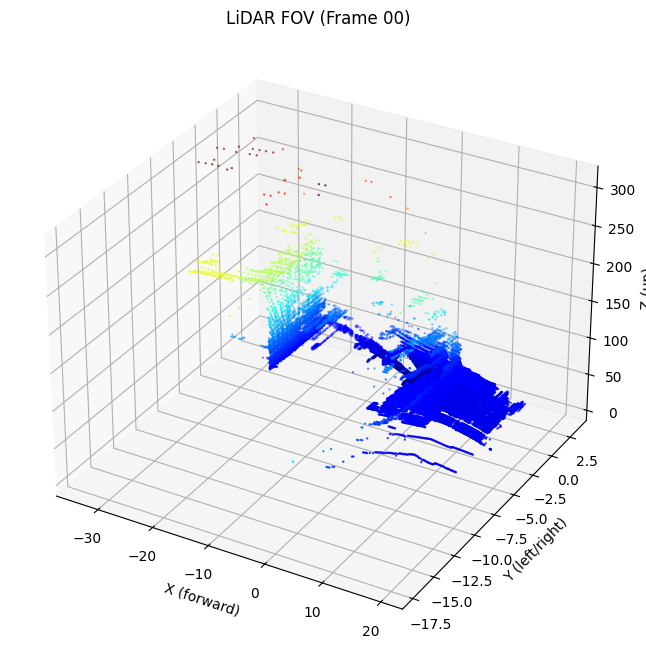

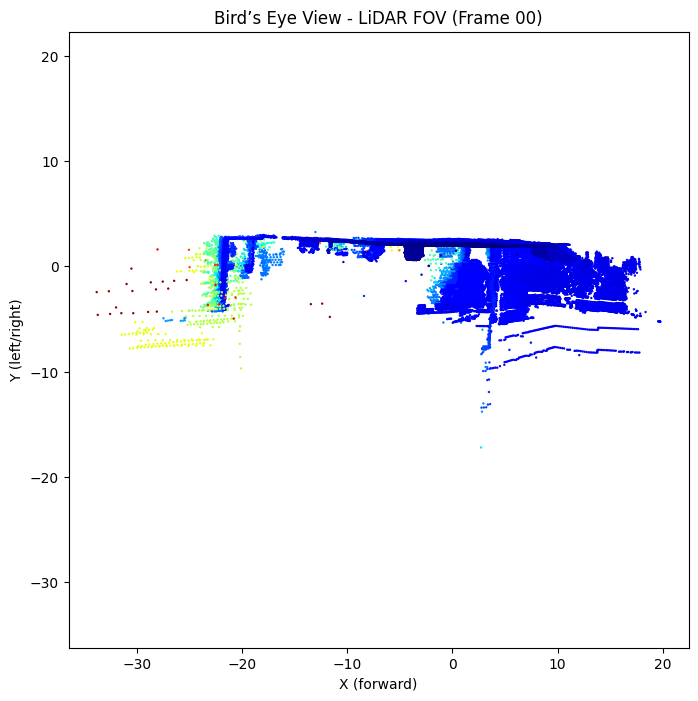

In [61]:
import os
import pickle
import numpy as np
import matplotlib.pyplot as plt

# Path to your saved lidar_fov files
lidar_fov_path = "/media/bvb/SSD-1/panda/pandaset-devkit-master/data/pandaset/001/lidar_fov"

# Choose a frame to visualize
frame_id = "00"
lidar_file = os.path.join(lidar_fov_path, f"{frame_id}.pkl")

# Load lidar_fov points
with open(lidar_file, "rb") as f:
    lidar_points = pickle.load(f)   # Nx3 (x,y,z)

print(f"Loaded {len(lidar_points)} points from {lidar_file}")

# Convert to numpy array
lidar_points = np.array(lidar_points)

# --- 3D scatter plot ---
fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection="3d")
ax.scatter(lidar_points[:, 0], lidar_points[:, 1], lidar_points[:, 2],
           c=lidar_points[:, 2], cmap="jet", s=0.5)
ax.set_xlabel("X (forward)")
ax.set_ylabel("Y (left/right)")
ax.set_zlabel("Z (up)")
ax.set_title("LiDAR FOV (Frame " + frame_id + ")")
plt.show()

# --- 2D Bird’s Eye View (Top Down) ---
plt.figure(figsize=(8, 8))
plt.scatter(lidar_points[:, 0], lidar_points[:, 1],
            c=lidar_points[:, 2], cmap="jet", s=0.5)
plt.xlabel("X (forward)")
plt.ylabel("Y (left/right)")
plt.title("Bird’s Eye View - LiDAR FOV (Frame " + frame_id + ")")
plt.axis("equal")
plt.show()


In [64]:
import pickle
import numpy as np
import open3d as o3d

# --- File path ---
lidar_file = "/media/bvb/SSD-1/panda/pandaset-devkit-master/data/pandaset/001/lidar_fov/00.pkl"

# --- Load lidar points (Nx3 array) ---
with open(lidar_file, "rb") as f:
    points = pickle.load(f)   # numpy.ndarray of shape (N,3)

print("Loaded LiDAR points:", points.shape)

# --- Create Open3D point cloud ---
pcd = o3d.geometry.PointCloud()
pcd.points = o3d.utility.Vector3dVector(points)

# Optional: colorize points (all gray)
pcd.paint_uniform_color([0.5, 0.5, 0.5])

# --- Visualize ---
o3d.visualization.draw_geometries([pcd],
                                  window_name="LiDAR FOV",
                                  width=1280, height=720,
                                  left=50, top=50,
                                  point_show_normal=False)


Loaded LiDAR points: (68453, 3)
